# Calculate product footprints and generate hotspot figure

**Related publication**

 - Title: Residual biomass to bio-based chemicals and plastics: ex-ante screening methodology for prioritizing high-impact substitutions
 - Authors: [Nicolas LIENART](https://orcid.org/0009-0001-3259-2819), [Thibaut LECOMPTE](https://orcid.org/0000-0001-9237-8454), [Lorie HAMELIN](https://orcid.org/0000-0001-9092-1900) 
 - Journal: Resources, Conservation and Recycling (RCR) - Elsevier
 - Doi: #todo
 - Code author: Nicolas LIENART
 - Git repository (Forge INRAE): https://forge.inrae.fr/nicolas.lienart/screen-lca-paper-supplementary-code
 - Git repository (GitHub): https://github.com/nicolnt/screen-lca-paper-supplementary-code

**Description and details**

This code generates the hotspot figure (Figure 2) showing the import and production amount of chemicals and plastics in the EU27, their unit GHG footprint (cradle-to-gate), the total estimated footprint (cradle-to-gate) and the estimated end of life impacts. Refer to the aforementioned main manuscript and accompanying supplementary information documents for more details.

**Updates**

 - May 04, 2026: Ready for submission

**Package versions**

 - See [`environment.yml`](./environment.yml)

**Relevant references**

ChatGPT was used to help with the SVG post-treatment.

- Prompts:
  - `Using matplotlib, I want to export the figure as a svg. But instead of each bars of each plt.bar having a name as "patch_xx" and containing "pathxx", where xx are digits, I want it to have meaningful names, based on dataframe data and index. How shoul I proceed?`
  - `How can I put all bars in "ax.bar" in a same parent svg group, also named.`
  - `This does not work, I get the following error: AttributeError: 'BarContainer' object has no attribute 'set_gid'`
  - `How can I make pyplot to stop putting single paths in groups when exporting to svg?`
  - `Using XPath syntax, how do I select all groups that are in the group with id="hello"`
- Public link: https://chatgpt.com/share/693bf85f-d4bc-8009-9538-189cdfdd7e83

## Initialization

In [2]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import pandas as pd
import numpy as np

10:34:05+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


In [1]:
from importlib.metadata import version
print('bw2data:', version('bw2data'))
print('bw2io:', version('bw2io'))
print('bw2calc:', version('bw2calc'))
print('pandas:', version('pandas'))
print('numpy:', version('numpy'))
print('matplotlib:', version('matplotlib'))

bw2data: 4.6.2
bw2io: 0.9.17
bw2calc: 2.4.0
pandas: 2.2.3
numpy: 2.4.3
matplotlib: 3.10.9


## Get Ecoinvent account login details from a different file

Your `.env` file is a collection of key-value pairs, separated by a `=` sign. It should contain these lines with the relevant values:

```bash
ecoinvent_username="replace_with your Ecoinvent's licence username"
ecoinvent_password="replace_with your Ecoinvent's licence password"
project_name="replace with project name"
```

We can then access this information with the dotenv and Python's built-in `os` libraries.

In [1]:
import os
from dotenv import load_dotenv  # To read the contents of the .env file

load_dotenv(override=True)
ECOINVENT_USERNAME = os.getenv("ecoinvent_username")
ECOINVENT_PASSWORD = os.getenv("ecoinvent_password")
PROJECT_NAME = os.getenv("project_name")

## Setup project

In [ ]:
bd.projects

In [5]:
bd.projects.set_current(name=PROJECT_NAME)
bd.projects.current

'template-ecoinvent-3.11-cutoff'

### Import Ecoinvent (only required once)

In [7]:
import json
ecoinvent_logins_json_file = 'ecoinvent-logins.json'

with open(ecoinvent_logins_json_file) as ecoinvent_logins_json_file:
    ecoinvent_logins = json.load(ecoinvent_logins_json_file)

In [ ]:
bi.import_ecoinvent_release(
    version='3.11',
    system_model='cutoff',
    username=ECOINVENT_USERNAME, 
    password=ECOINVENT_PASSWORD 
)

In [4]:
bd.databases

Databases dictionary with 2 object(s):
	ecoinvent-3.11-biosphere
	ecoinvent-3.11-cutoff

## Import CSV data

In [ ]:
ei = bd.Database('ecoinvent-3.11-cutoff')

In [ ]:
# NOTE: CSV file format must be as below
# PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms

input_table = pd.read_csv('Prodcom_data/20260326 - data input.csv')

In [9]:
input_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms
0,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.08100,3
1,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08000,3
2,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05000,2
3,20161050,Polyethylene having a specific gravity of >= 0...,Polyethylene,7.209667,"market for polyethylene, high density, granulate",(C2H4)n,28.05400,2
4,20142210,Methanol (methyl alcohol),Methanol,7.123081,market for methanol,CH4O,32.04200,1
5,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11000,6
6,20163010,"Polyvinyl chloride, not mixed with any other s...",Polyvinyl chloride,4.830409,"market for polyvinyl chloride, emulsion polyme...",C2H3Cl,62.50000,2
7,20161039,"Polyethylene having a specific gravity < 0,94,...",Polyethylene,4.233640,"market for polyethylene, low density, granulate",(C2H4)n,28.05400,2
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13000,8
9,20164062,Polyethylene terephthalate in primary forms ha...,Polyethylene terephthalate,3.309299,"market for polyethylene terephthalate, granula...",C12H14O4,222.24000,12


## LCA code

In [10]:
# NOTE: Select the right method
# ef_gwp_key = [m for m in bd.methods if m[0] == "ecoinvent-3.11" and "climate change" == m[2] and "EF v3.1" == m[1]][0]
ef_gwp_key = [m for m in bd.methods if m[0] == "ecoinvent-3.11" and "climate change: total (excl. biogenic CO2)" == m[2] and "IPCC 2021" == m[1] and "global warming potential (GWP100)" == m[3]][0]
ef_gwp_key

('ecoinvent-3.11',
 'IPCC 2021',
 'climate change: total (excl. biogenic CO2)',
 'global warming potential (GWP100)')

In [12]:
# NOTE: Prepare LCA object
random_activity = ei.random()
lca = bc.LCA(demand={random_activity.id: 1}, method=ef_gwp_key)
lca.lci()
lca.lcia()

In [13]:
def calculate_LCA(code):
    activity = ei.get(code)

    # NOTE: Not needed
    # my_functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    #     demand={activity: 1},
    #     method=ef_gwp_key,
    # )


    # NOTE: Instantiate LCA for every run
    # my_lca = bc.LCA(demand={activity.id: 1}, method=ef_gwp_key)
    # my_lca.lci()
    
    # NOTE: Reuse the LCA object created before. No big improvement. Source: https://github.com/brightway-lca/brightway2/blob/master/notebooks/Using%20redo_lci%20and%20redo_lcia.ipynb
    lca.lci(demand={activity.id: 1})
    # my_lca.redo_lci(demand={activity.id: 1}) # NOTE: Deprecated: https://docs.brightway.dev/en/latest/content/changelog/link_to_changelog_calc.html#dev4-2021-11-03
    
    lca.lcia()
    
    return lca.score

In [14]:
def browse_exchanges_until_product(product_code, product_CAS, product_name, list_of_constituents, n, cutoff=1):
    activity = ei.get(product_code)
    
    # NOTE: Reached the end of the recursive call.
    if n == 0:
        return 0
    
    else:        
        # NOTE: For each technosphere exchanges except itself
        exchanges = [m for m in activity.exchanges() if m['type'] == 'technosphere']
        
        if len(exchanges) > 0:
            score = 0
            for exchange in exchanges:

                exchange_code = exchange['input'][1]
                # exchange_activity = ei.get(exchange_code)
                # exchange_activity_name = exchange_activity['name']
                # exchange_activity_name_and_location = f'{exchange_activity_name} ({'---' if 'location' not in exchange_activity else exchange_activity['location']})'
                amount = exchange['amount']
                
                # NOTE: Optimisation: Check if activity ISIC code is != than '19', '20', '21', '22'
                isic_code = ''
                if 'classifications' in exchange.input.as_dict() \
                    and len([e for e in exchange.input.as_dict()['classifications'] if e[0] == 'ISIC rev.4 ecoinvent']) > 0:
                    isic_code = [e for e in exchange.input.as_dict()['classifications'] if e[0] == 'ISIC rev.4 ecoinvent'][0][1]
                if isic_code == '' or isic_code[0:2] not in ['19', '20', '21', '22']:
                    # print(f'{"—"*(10-n)}STOP: ISIC code does not match {exchange_activity_name_and_location} ({isic_code[0:2]})')
                    continue

                # NOTE: Optimisation: Apply a cutoff on the mass
                newcutoff = cutoff
                if exchange['unit'] == activity['unit'] and activity['unit'] == 'kilogram':
                    share = exchange['amount'] / activity['production amount']
                    if share < cutoff:
                        # print(f'STOP: below cutoff {exchange_activity_name_and_location} ({exchange['amount'] / activity['production amount']} < {cutoff})')
                        continue
                    else:
                        newcutoff = cutoff * (1/share)
                        # cutoff = cutoff * (1/share)
                # NOTE: If CAS or name is matched, calculate and return footprint and stop there.
                if ('CAS number' in exchange and exchange['CAS number'] == product_CAS) \
                    or exchange['name'].lower() == product_name.lower():
                    # print(f'CALC: {exchange_activity_name_and_location} for constituent {product_name}')
                    lca_score = calculate_LCA(code=exchange_code)
                    score += amount * lca_score
                # NOTE: If CAS or name is matched, don't calculate footprint and stop there, otherwise recursively call the function on the exchange
                elif (('CAS number' not in exchange) \
                    or ('CAS number' in exchange and exchange['CAS number'] not in [e['CAS'] for e in list_of_constituents])) \
                    or (exchange['name'].lower() not in [e['name'].lower() for e in list_of_constituents]):
                    # print(f'STEP IN: {exchange_activity_name_and_location} for constituent {product_name}, step in')
                    score += amount * browse_exchanges_until_product(exchange_code, product_CAS, product_name, list_of_constituents,
                                                                     n=n-1,
                                                                     cutoff=newcutoff)
                # else: print(f'STOP: nothing {exchange_activity_name_and_location} for constituent {product_name}')
            return score
        
        # NOTE: No exchanges?
        else:
            return 0

In [15]:
def getRelevantActivity(name, location_priority=['RER', 'GLO', 'RoW']):
    activities = [a for a in ei.search(name) if a['name'] == name]
    
    if len(activities) > 0:
        for location in location_priority:
            activities_location = [a for a in activities if a['location'] == location]
            if len(activities_location):
                return activities_location[0]
            
        return activities.random() # Situation not encountered with this case study, dataset exist for either of 'RER', 'GLO' or 'RoW'

    else:
        return None

In [26]:
impact_data = input_table.copy()
impact_data[['ecoinvent activity region','GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)']] = ['', float('nan')]

In [54]:
# impact_data = impact_data.loc[impact_data['PRCCODE (Codes)'] == '20165130']
# impact_data = impact_data.loc[impact_data['Ecoinvent cutoff 3.11'] == 'market for polypropylene, granulate']

In [17]:
list_of_constituents = [
    {
        "name":'propylene',
        "CAS":'115-07-1'
    },
    {
        "name":'ethylene',
        "CAS":'74-85-1'
    },
    {
        "name":'methanol',
        "CAS":'000067-56-1'
    },
    {
        "name":'xylene, mixed',
        "CAS":'',
        "type": "BTX"
    },
    {
        "name":'o-xylene',
        "CAS":'000095-47-6',
        "type": "BTX"
    },
    {
        "name":'p-xylene',
        "CAS":'000106-42-3',
        "type": "BTX"
    },
    {
        "name":'toluene, liquid',
        "CAS":'108-88-3',
        "type": "BTX"
    },
    {
        "name":'benzene',
        "CAS":'000071-43-2',
        "type": "BTX"
    }
]

In [27]:
# NOTE: Add constituents columns
impact_data[[e['name'] for e in list_of_constituents]] = [float('nan') for e in list_of_constituents]

In [28]:
impact_data

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene
0,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.08100,3,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08000,3,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05000,2,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20161050,Polyethylene having a specific gravity of >= 0...,Polyethylene,7.209667,"market for polyethylene, high density, granulate",(C2H4)n,28.05400,2,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20142210,Methanol (methyl alcohol),Methanol,7.123081,market for methanol,CH4O,32.04200,1,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11000,6,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,20163010,"Polyvinyl chloride, not mixed with any other s...",Polyvinyl chloride,4.830409,"market for polyvinyl chloride, emulsion polyme...",C2H3Cl,62.50000,2,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,20161039,"Polyethylene having a specific gravity < 0,94,...",Polyethylene,4.233640,"market for polyethylene, low density, granulate",(C2H4)n,28.05400,2,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13000,8,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,20164062,Polyethylene terephthalate in primary forms ha...,Polyethylene terephthalate,3.309299,"market for polyethylene terephthalate, granula...",C12H14O4,222.24000,12,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
ef_gwp_key = [m for m in bd.methods if m[0] == "ecoinvent-3.11" and "climate change" == m[2] and "EF v3.1" == m[1]][0]

In [29]:
# NOTE: Take less than one minute (less than 100 products)
#location_priority=['RER', 'GLO', 'RoW']
location_priority=None


for index in impact_data.index.values:
    

    if impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'].startswith('manual:'):
        score = float(impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'].split(':')[1])
    else:
        if location_priority:
            activity = getRelevantActivity(impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'], location_priority)
        else:
            activity = getRelevantActivity(impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'])

        print(f'Product: {impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy']}, {activity['location']}')
        
        impact_data.loc[index, 'ecoinvent activity region'] = activity['location']
        

        my_functional_unit, data_objs, _ = bd.prepare_lca_inputs(
            demand={activity: 1},
            method=ef_gwp_key,
        )
        my_lca = bc.LCA(demand=my_functional_unit, data_objs=data_objs)
        my_lca.lci()
        my_lca.lcia()
        # print('unit impact:', my_lca.score)
        score = my_lca.score
    

        
    if location_priority is not None:
        impact_data.loc[index, 'conseq_'+'_'.join(location_priority)] = score
    else:
        impact_data.loc[index, 'GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'] = score

    # print('----------')

    # if index == 5:
    #     break

Product: market for polypropylene, granulate, GLO
Product: market for propylene, RER
Product: market for ethylene, RER
Product: market for polyethylene, high density, granulate, GLO
Product: market for methanol, RER
Product: market for benzene, RER
Product: market for polyvinyl chloride, emulsion polymerised, RER
Product: market for polyethylene, low density, granulate, GLO
Product: market for purified terephthalic acid, GLO
Product: market for polyethylene terephthalate, granulate, amorphous, GLO
Product: market for styrene, RER
Product: market for polyethylene, linear low density, granulate, GLO
Product: market for butadiene, RER
Product: market for butene, mixed, RER
Product: market for polystyrene, extruded, GLO
Product: market for propylene oxide, liquid, RER
Product: market for ethylene glycol, RER
Product: market for polystyrene, expandable, GLO
Product: market for vinyl acetate, RER
Product: market for acetone, liquid, RER
Product: market for ethylene dichloride, RER
Product: m

In [30]:
# NOTE: Take less than five minutes (less than 100 products)
cutoff_ratio = 0.05
iterations = 10

for index in impact_data.index.values:

    if impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'].startswith('manual:'):
        impact_data.loc[index, [e['name'].lower() for e in list_of_constituents]] = 0.0

    else:
        activity = getRelevantActivity(impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'])
        print(f'Product: {impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy']}, {activity['location']}')
        
        for constituent in list_of_constituents:
                # if constituent['name'] == 'propylene':
                if impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy'].startswith('manual:'):
                    constituent_score = 0
                else:
                    cutoff_amount = activity['production amount']*cutoff_ratio
                    constituent_score = browse_exchanges_until_product(product_code=activity['code'],
                                                                    product_CAS=constituent['CAS'],
                                                                    product_name=constituent['name'],
                                                                    list_of_constituents=list_of_constituents,
                                                                    n=iterations,
                                                                    cutoff=cutoff_amount)
                    # print(f'{constituent['name'].capitalize()} (CAS: {constituent['CAS']}): {constituent_score}')
                    
                impact_data.loc[index, constituent['name'].lower()] = constituent_score

Product: market for polypropylene, granulate, GLO
Product: market for propylene, RER
Product: market for ethylene, RER
Product: market for polyethylene, high density, granulate, GLO
Product: market for methanol, RER
Product: market for benzene, RER
Product: market for polyvinyl chloride, emulsion polymerised, RER
Product: market for polyethylene, low density, granulate, GLO
Product: market for purified terephthalic acid, GLO
Product: market for polyethylene terephthalate, granulate, amorphous, GLO
Product: market for styrene, RER
Product: market for polyethylene, linear low density, granulate, GLO
Product: market for butadiene, RER
Product: market for butene, mixed, RER
Product: market for polystyrene, extruded, GLO
Product: market for propylene oxide, liquid, RER
Product: market for ethylene glycol, RER
Product: market for polystyrene, expandable, GLO
Product: market for vinyl acetate, RER
Product: market for acetone, liquid, RER
Product: market for ethylene dichloride, RER
Product: m

In [31]:
impact_data

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene
0,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.08100,3,GLO,3.049226,2.289804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08000,3,RER,1.820997,1.820997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05000,2,RER,1.820997,0.000000,1.820997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,20161050,Polyethylene having a specific gravity of >= 0...,Polyethylene,7.209667,"market for polyethylene, high density, granulate",(C2H4)n,28.05400,2,GLO,2.830391,0.000000,2.063423,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,20142210,Methanol (methyl alcohol),Methanol,7.123081,market for methanol,CH4O,32.04200,1,RER,0.899816,0.000000,0.000000,0.870933,0.000000,0.000000,0.000000,0.000000,0.000000
5,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11000,6,RER,2.064759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.018399
6,20163010,"Polyvinyl chloride, not mixed with any other s...",Polyvinyl chloride,4.830409,"market for polyvinyl chloride, emulsion polyme...",C2H3Cl,62.50000,2,RER,2.384931,0.000000,0.766178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,20161039,"Polyethylene having a specific gravity < 0,94,...",Polyethylene,4.233640,"market for polyethylene, low density, granulate",(C2H4)n,28.05400,2,GLO,2.966325,0.000000,2.052390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13000,8,GLO,2.522800,0.000000,0.000000,0.000000,0.000000,0.000000,1.602838,0.000000,0.000000
9,20164062,Polyethylene terephthalate in primary forms ha...,Polyethylene terephthalate,3.309299,"market for polyethylene terephthalate, granula...",C12H14O4,222.24000,12,GLO,3.752404,0.000000,0.309966,0.000000,0.000000,0.000000,1.314330,0.000000,0.000000


In [ ]:
impact_data.to_csv('output/data output.csv')

In [ ]:
#impact_data.to_clipboard()

## Manipulate output

In [32]:
# NOTE: Preserve previous data, just in case
output_table = impact_data.copy()
# output_table = impact_data.loc[0:5].copy()

In [ ]:
# NOTE: Import from already exported previous result
output_table = pd.read_csv('output/data output.csv')
output_table = output_table.drop(output_table.columns[0], axis=1)

In [33]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene
0,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.08100,3,GLO,3.049226,2.289804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08000,3,RER,1.820997,1.820997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05000,2,RER,1.820997,0.000000,1.820997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,20161050,Polyethylene having a specific gravity of >= 0...,Polyethylene,7.209667,"market for polyethylene, high density, granulate",(C2H4)n,28.05400,2,GLO,2.830391,0.000000,2.063423,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,20142210,Methanol (methyl alcohol),Methanol,7.123081,market for methanol,CH4O,32.04200,1,RER,0.899816,0.000000,0.000000,0.870933,0.000000,0.000000,0.000000,0.000000,0.000000
5,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11000,6,RER,2.064759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.018399
6,20163010,"Polyvinyl chloride, not mixed with any other s...",Polyvinyl chloride,4.830409,"market for polyvinyl chloride, emulsion polyme...",C2H3Cl,62.50000,2,RER,2.384931,0.000000,0.766178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,20161039,"Polyethylene having a specific gravity < 0,94,...",Polyethylene,4.233640,"market for polyethylene, low density, granulate",(C2H4)n,28.05400,2,GLO,2.966325,0.000000,2.052390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13000,8,GLO,2.522800,0.000000,0.000000,0.000000,0.000000,0.000000,1.602838,0.000000,0.000000
9,20164062,Polyethylene terephthalate in primary forms ha...,Polyethylene terephthalate,3.309299,"market for polyethylene terephthalate, granula...",C12H14O4,222.24000,12,GLO,3.752404,0.000000,0.309966,0.000000,0.000000,0.000000,1.314330,0.000000,0.000000


In [34]:
duplicate_rows = output_table['Figure name'].duplicated(keep=False)
duplicate_figure_names = output_table[duplicate_rows]['Figure name'].unique()
duplicate_figure_names

array(['Polyethylene', 'Polyvinyl chloride', 'Polyethylene terephthalate',
       'Polystyrene', 'Polyvinyl acetate'], dtype=object)

In [36]:
# NOTE: Grouping
columns = ['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)', 'propylene', 'ethylene',
           'methanol', 'xylene, mixed', 'o-xylene',
           'p-xylene', 'toluene, liquid', 'benzene']

# unique_groups = list(set(output_table[output_table['Grouping'].notnull()].loc[:, 'Grouping'].to_list()))
grouped_df = pd.DataFrame(columns=output_table.columns)


for index in range(len(duplicate_figure_names)):
    group_name = duplicate_figure_names[index]
    
    group_duplicate_rows = output_table[output_table['Figure name'] == group_name]

    # Sum quantity
    quantity_df = group_duplicate_rows.loc[:, 'Quantity (Mt)']
    total_quantity = quantity_df.sum()

    # Set row value
    grouped_df.loc[index, 'PRODCOM code'] = np.nan
    grouped_df.loc[index, 'Figure name'] = group_name
    grouped_df.loc[index, 'Quantity (Mt)'] = total_quantity
    grouped_df.loc[index, 'Molecular formula (MF)'] = group_duplicate_rows.iloc[0]['Molecular formula (MF)']
    grouped_df.loc[index, 'Molecular weight (MW)'] = group_duplicate_rows.iloc[0]['Molecular weight (MW)']
    grouped_df.loc[index, 'Carbon atoms'] = group_duplicate_rows.iloc[0]['Carbon atoms']

    for column in columns:
        unit_impact_df = group_duplicate_rows.loc[:, column]
        unit_impact = quantity_df.dot(unit_impact_df)/total_quantity
        grouped_df.loc[index, column] = unit_impact

#group_name = 'Polyamide'
grouped_df
# output_table.loc[0, 'Grouping']

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,0.0,2.035186,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,0.0,0.76583,0.0,0.0,0.0,0.0,0.0,0.0
2,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,0.0,0.309966,0.0,0.0,0.0,1.31433,0.0,0.0
3,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NaN,NaN,Polyvinyl acetate,1.394641,NaN,(C4H6O2)x,86.09,4,NaN,3.742413,0.0,0.605482,0.421002,0.0,0.0,0.0,0.0,0.0


In [37]:
# NOTE: merge non duplicate rows with the groupped duplicate rows (not necessary all the time)

# Select non duplicate rows
not_duplicate_rows = output_table[~duplicate_rows]
output_table = pd.concat([not_duplicate_rows, grouped_df], ignore_index=True)

In [38]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene
0,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,2.289804,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,1.820997,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,0.0,1.820997,0.0,0.0,0.0,0.0,0.0,0.0
3,20142210,Methanol (methyl alcohol),Methanol,7.123081,market for methanol,CH4O,32.042,1,RER,0.899816,0.0,0.0,0.870933,0.0,0.0,0.0,0.0,0.0
4,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.018399
5,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,0.0,0.0,0.0,0.0,0.0,1.602838,0.0,0.0
6,20141250,Styrene,Styrene,2.99224,market for styrene,C8H8,104.15,8,RER,3.220284,0.0,0.5117,0.0,0.0,0.0,0.0,0.0,1.608448
7,20141160,"Buta-1,3-diene and isoprene",Butadiene,2.049547,market for butadiene,C4H6,54.09,4,RER,2.668062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,20141150,Butene (butylene) and isomers thereof,Butylene,1.800077,"market for butene, mixed",C8H16,112.21,8,RER,1.823771,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,20146375,Methyloxirane (propylene oxide),Propylene oxide,1.512055,"market for propylene oxide, liquid",C3H6O,58.08,3,RER,3.958796,1.389421,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# NOTE: Calculate GHG unit impact of end-of-life value
output_table[['GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
Carbon_atomic_mass = 12.011
Carbon_to_CO2 = 44/12

for index, row in output_table.iterrows():

    carbon_mass_share = (output_table.loc[index]['Carbon atoms']*Carbon_atomic_mass/output_table.loc[index]['Molecular weight (MW)'])
    output_table.at[index,'GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = carbon_mass_share

In [40]:
# NOTE: Calculate total GHG unit impact with end-of-life
output_table[['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    y_value = output_table.loc[index]['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'] + output_table.loc[index]['GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']
    output_table.at[index,'GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = y_value

In [41]:
# NOTE: Calculate total value without end-of-life
output_table[['Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    y_value = output_table.loc[index]['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'] * output_table.loc[index]['Quantity (Mt)']
    output_table.at[index,'Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = y_value

In [42]:
# NOTE: Calculate total value with end-of-life
output_table[['Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    y_value = output_table.loc[index]['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] * output_table.loc[index]['Quantity (Mt)']
    output_table.at[index,'Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = y_value

In [43]:
# NOTE: Sort data
output_table.sort_values(by=['Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'], ascending=False, inplace=True, ignore_index=True)

In [44]:
# NOTE: Calculate x value
output_table[['x_axis']] = [float('nan')]
for index, row in output_table.iterrows():
    if index == 0:
        x_value = 0
    else:
        x_value = output_table.loc[index-1]['x_axis'] + output_table.loc[index-1]['Quantity (Mt)']
    output_table.at[index,'x_axis'] = x_value

In [101]:
#output_table.drop(56, inplace=True)

In [45]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",...,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,...,0.0,0.0,0.0,0.0,0.0,0.856277,3.716663,40.121481,52.132138,0.000000
1,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,...,0.0,0.0,0.0,0.0,0.0,0.856277,3.905503,31.830559,40.769151,14.026599
2,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,...,0.0,0.0,0.0,0.0,0.0,0.922575,8.202318,22.697806,25.574338,24.465499
3,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,...,0.0,0.0,0.0,0.0,0.0,0.856298,2.677295,17.081623,25.114008,27.583439
4,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,...,0.0,0.0,0.0,0.0,0.0,0.856399,2.677397,16.834147,24.751100,36.963805
5,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,...,0.0,0.0,1.31433,0.0,0.0,0.648542,4.400946,15.349142,18.001992,46.208270
6,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,...,0.0,0.0,0.0,0.0,2.018399,0.922622,2.987381,12.369087,17.896120,50.298753
7,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,...,0.0,0.0,0.0,0.0,0.0,0.384352,2.728956,13.154088,15.310443,56.289324
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,...,0.0,0.0,1.602838,0.0,0.0,0.578390,3.101191,10.174336,12.506958,61.899690
9,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.8,30,RER,9.306555,...,0.0,0.0,0.0,0.0,0.0,0.618274,9.924829,11.695370,12.472343,65.932643


### Sum BTX values

In [46]:
# NOTE: Calculate total BTX value
output_table[['BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    btx_total = row.loc[['xylene, mixed', 'o-xylene', 'p-xylene', 'toluene, liquid', 'benzene']].sum()
    output_table.at[index,'BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)'] = btx_total

In [47]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",...,o-xylene,p-xylene,"toluene, liquid",benzene,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis,"BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)"
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,...,0.0,0.0,0.0,0.0,0.856277,3.716663,40.121481,52.132138,0.000000,0.000000
1,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,...,0.0,0.0,0.0,0.0,0.856277,3.905503,31.830559,40.769151,14.026599,0.000000
2,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,...,0.0,0.0,0.0,0.0,0.922575,8.202318,22.697806,25.574338,24.465499,0.000000
3,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,...,0.0,0.0,0.0,0.0,0.856298,2.677295,17.081623,25.114008,27.583439,0.000000
4,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,...,0.0,0.0,0.0,0.0,0.856399,2.677397,16.834147,24.751100,36.963805,0.000000
5,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,...,0.0,1.31433,0.0,0.0,0.648542,4.400946,15.349142,18.001992,46.208270,1.314330
6,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,...,0.0,0.0,0.0,2.018399,0.922622,2.987381,12.369087,17.896120,50.298753,2.018399
7,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,...,0.0,0.0,0.0,0.0,0.384352,2.728956,13.154088,15.310443,56.289324,0.000000
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,...,0.0,1.602838,0.0,0.0,0.578390,3.101191,10.174336,12.506958,61.899690,1.602838
9,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.8,30,RER,9.306555,...,0.0,0.0,0.0,0.0,0.618274,9.924829,11.695370,12.472343,65.932643,0.000000


In [ ]:
output_table.to_csv('output/data output - processed.csv')

## Create figure

In [ ]:
# NOTE: Import CSV from already exported data
output_table = pd.read_csv('output/data output - processed.csv', nrows=50)
output_table = output_table.drop(output_table.columns[0], axis=1)

In [48]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",...,o-xylene,p-xylene,"toluene, liquid",benzene,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis,"BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)"
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,...,0.0,0.0,0.0,0.0,0.856277,3.716663,40.121481,52.132138,0.000000,0.000000
1,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,...,0.0,0.0,0.0,0.0,0.856277,3.905503,31.830559,40.769151,14.026599,0.000000
2,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,...,0.0,0.0,0.0,0.0,0.922575,8.202318,22.697806,25.574338,24.465499,0.000000
3,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,...,0.0,0.0,0.0,0.0,0.856298,2.677295,17.081623,25.114008,27.583439,0.000000
4,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,...,0.0,0.0,0.0,0.0,0.856399,2.677397,16.834147,24.751100,36.963805,0.000000
5,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,...,0.0,1.31433,0.0,0.0,0.648542,4.400946,15.349142,18.001992,46.208270,1.314330
6,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,...,0.0,0.0,0.0,2.018399,0.922622,2.987381,12.369087,17.896120,50.298753,2.018399
7,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,...,0.0,0.0,0.0,0.0,0.384352,2.728956,13.154088,15.310443,56.289324,0.000000
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,...,0.0,1.602838,0.0,0.0,0.578390,3.101191,10.174336,12.506958,61.899690,1.602838
9,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.8,30,RER,9.306555,...,0.0,0.0,0.0,0.0,0.618274,9.924829,11.695370,12.472343,65.932643,0.000000


In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [50]:
def add_labels_total_impact(ax, x, quantity, y, amount, id):
    for i in range(len(x)):
        gid = f"annotation_total_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}', xy=(x[i] + quantity[i]/2, y[i]), rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [51]:
def add_labels_quantities(ax, x, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_quantity_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}', xy=(x[i] + quantity[i]/2, -0.2), rotation=45,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.annotate(text=f'{round(label[i], 1)} Mt', xy=(x[i] + quantity[i]/2, -0.2), rotation=0,
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [52]:
def add_labels_id(ax, x, y, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1) if type(amount[i]) is float else amount[i]}',
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center

In [53]:
def add_labels_unit_impact(ax, x, y, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_unit_impact_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}', xy=(x[i] + quantity[i]/2, y[i]+0.5), rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=8, gid=gid)  # Aligning text at center

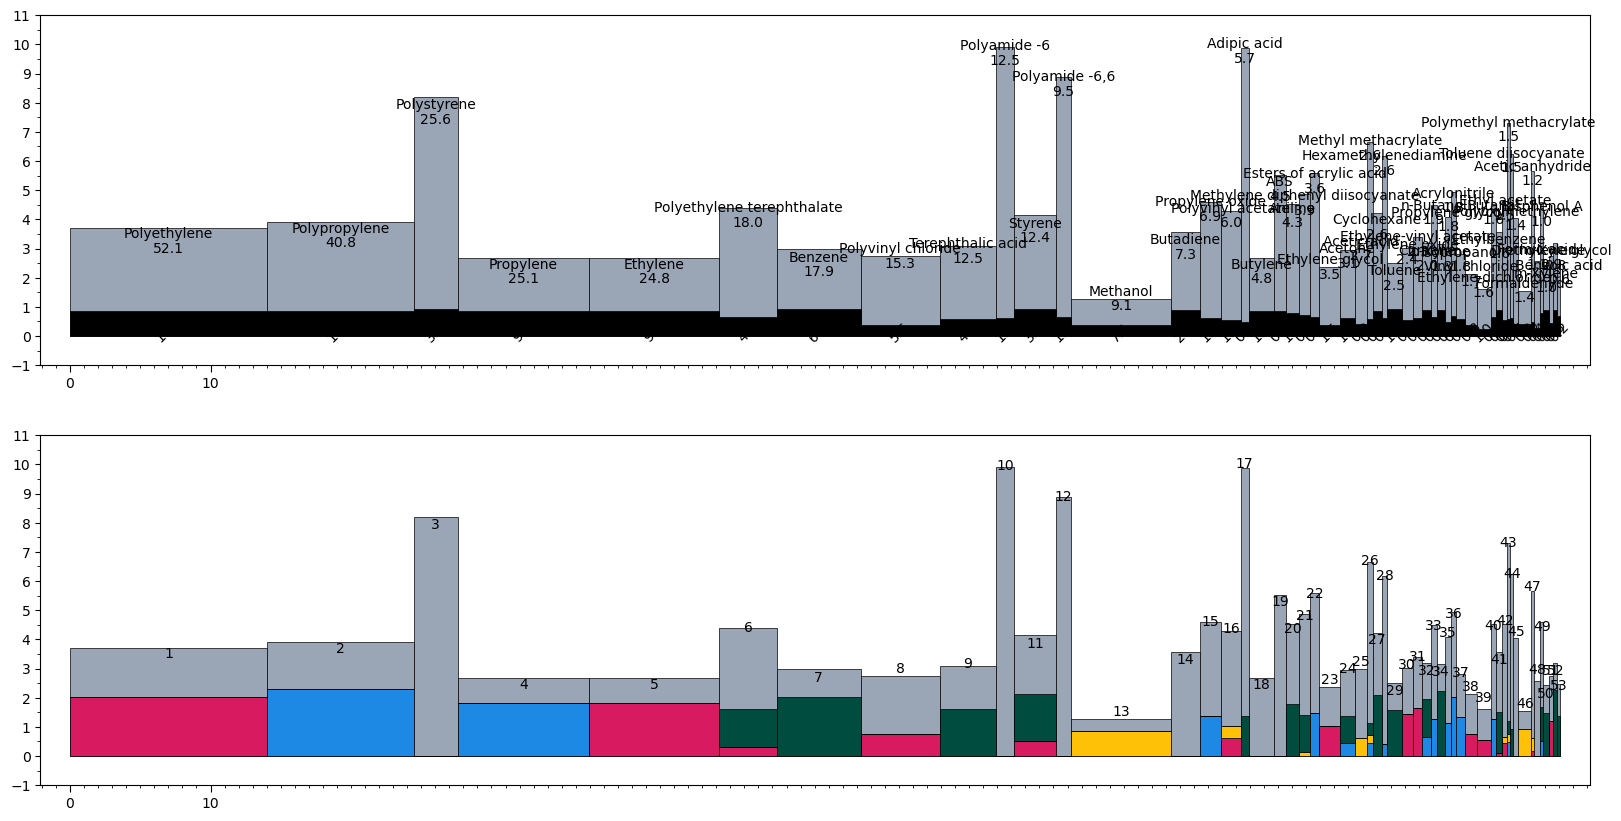

In [ ]:
color_palette = ["#9aa6b6", "#d81b60", '#1e88e5','#ffc107','#004d40']

figure = plt.figure(figsize=(20, 10))
plt.rcParams['svg.fonttype'] = 'none'
(ax_1, ax_2) = figure.subplots(2, 1)
#plt.tight_layout()
total_bars = ax_2.bar(x=output_table['x_axis'],
                      height=output_table['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'], width=output_table['Quantity (Mt)'],
                      align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[0])
for bar, (idx, row) in zip(total_bars, output_table.iterrows()):
    gid = f"bar_totalaxes2_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)
ethylene_bars = ax_2.bar(x=output_table['x_axis'],
                         height=output_table['ethylene'],
                         width=output_table['Quantity (Mt)'], 
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[1])
for bar, (idx, row) in zip(ethylene_bars, output_table.iterrows()):
    gid = f"bar_ethylene_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)
propylene_bars = ax_2.bar(x=output_table['x_axis'],
                          bottom=output_table['ethylene'],
                          height=output_table['propylene'],
                          width=output_table['Quantity (Mt)'],
                          align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[2])
for bar, (idx, row) in zip(propylene_bars, output_table.iterrows()):
    gid = f"bar_propylene_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)
methanol_bars = ax_2.bar(x=output_table['x_axis'],
                         bottom=output_table['ethylene']+output_table['propylene'],
                         height=output_table['methanol'],
                         width=output_table['Quantity (Mt)'],
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[3])
for bar, (idx, row) in zip(methanol_bars, output_table.iterrows()):
    gid = f"bar_methanol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

btx_bars = ax_2.bar(x=output_table['x_axis'],
                    bottom=output_table['ethylene']+output_table['propylene']+output_table['methanol'],
                    height=output_table['BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)'],
                    width=output_table['Quantity (Mt)'],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[4])
for bar, (idx, row) in zip(btx_bars, output_table.iterrows()):
    gid = f"bar_btx_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)


ax_2.set_ylim(bottom=-1, top=11)
ax_2.margins(x=0.02)
#ax.set_xlim(left=0, right=70000)
ax_2.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_2.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_2.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_2.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_2.tick_params(axis='x', which='major', length=5)
#ax_2.set_ymargin(1)


ax_1.set_ylim(bottom=-1, top=11)
ax_1.margins(x=0.02)
#ax.set_xlim(left=0, right=70000)
ax_1.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_1.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_1.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_1.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_1.tick_params(axis='x', which='major', length=5)


total_bars_ax_1 = ax_1.bar(x=output_table['x_axis'], height=output_table['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'],
                           width=output_table['Quantity (Mt)'], align='edge', edgecolor = 'k', linewidth = 0.5,
                           color=color_palette[0])
for bar, (idx, row) in zip(total_bars_ax_1, output_table.iterrows()):
    gid = f"bar_totalaxes1_{row['PRODCOM code']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

eol_bars = ax_1.bar(x=output_table['x_axis'],
                    # bottom=output_table['ethylene']+output_table['propylene']+output_table['methanol']+output_table['BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)'],
                    height=output_table['GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'],
                    width=output_table['Quantity (Mt)'],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color='black')
for bar, (idx, row) in zip(eol_bars, output_table.iterrows()):
    gid = f"bar_eol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)


add_labels_total_impact(ax=ax_1, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'], y=output_table['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'],
                        amount=output_table['Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'], id=output_table['Figure name'])
add_labels_quantities(ax=ax_1, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'],
                      amount=output_table['Quantity (Mt)'], id=output_table['Figure name'])
#add_labels_unit_impact(ax=ax_2, x=output_table['x_axis'], quantity=output_table['Quantity'], y=output_table['unit impact'], amount=output_table['unit impact'], id=output_table['PRCCODE (Labels)'])

add_labels_id(ax=ax_2, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'], y=output_table['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'],
              amount=pd.Series(output_table.index).apply(lambda x: x+1), id=output_table['Figure name'])

add_labels_id(ax=ax_1, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'], y=output_table['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'],
              amount=output_table['Figure name'], id=output_table['Figure name'])

In [ ]:
# NOTE: Save figure to file
# plt.savefig("output/figure.svg")

## Figure post-treatment

In [3]:
import xml.etree.ElementTree as ET

In [ ]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
# 3) Parse SVG and create a group wrapping the bars
# Note: the SVG has a default namespace; we handle it explicitly.
SVG_NS = "http://www.w3.org/2000/svg"
NS = {"svg": SVG_NS}
ET.register_namespace("", SVG_NS)  # preserve default namespace on write

tree = ET.parse('output/figure.svg')

In [5]:
import re

def postProcessSVG(root, axes_list=['axes_1', 'axes_2']):
    for axes in axes_list:
        axes_element = root.find(f".//svg:g[@id='{axes}']", NS)

        element_list = [e.get('id') for e in axes_element.findall(".//svg:g[@id]", NS)]
        patterns = []
        r = re.compile("^(.*?_.*?)_.*")

        for el in element_list:
            match = r.match(el)
            if match and match.group(1):
                pattern_group = match.group(1)
                patterns.append(pattern_group)

        patterns = list(reversed(list(set(patterns))))

        for pattern in patterns:
        
            # Find all elements that are bar paths/rects by id pattern "bar_..."
            # They might be <path> or <rect> depending on style/backend
            bar_elems = []
            for elem in axes_element.findall(".//svg:g", NS):
                eid = elem.get("id")
                if eid and eid.startswith(pattern):
                    bar_elems.append(elem)
            
            if not bar_elems:
                raise RuntimeError("No elements found with id starting 'bar_'. \
                                   Check the GIDs on bars and the SVG content.")
            else:
                bar_elems

            # Find where to insert the group: common place is as a child of the main <g> that contains axes.
            # We'll insert the new group as a child of the root SVG for simplicity.
            svg_group_element = ET.Element(f"{{{SVG_NS}}}g", {"id": f"group_{pattern}"})

            # Move each bar element into the new group.
            # Removing from the original parent requires finding that parent.
            def find_parent(root_node, child):
                for p in root_node.iter():
                    for c in p:
                        if c is child:
                            return p
                return None

            for e in bar_elems:
                parent = axes_element.find(f".//svg:g[@id='{e.get('id')}']/..", NS)
                # parent = find_parent(root, e)
                if parent is None:
                    continue
                parent.remove(e)
                svg_group_element.append(e)

            # Insert group into root (or into a suitable parent if you prefer)
            axes_element.append(svg_group_element)

In [6]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
def flatten(node):
    """Remove <g> elements that only contain a single child and no attributes."""
    for child in list(node):
        flatten(child)
    # If a <g> has only one child and no attributes other than id, flatten it
    for g in list(node.findall(f"{{{SVG_NS}}}g")):
        children = list(g)
        attrs = {k: v for k, v in g.attrib.items() if k != "id"}
        if len(children) == 1 and not attrs:
            child = children[0]
            if "id" in g.attrib and "id" not in child.attrib:
                child.attrib["id"] = g.attrib["id"]
            node.insert(list(node).index(g), child)
            node.remove(g)

In [7]:
root = tree.getroot()
postProcessSVG(root)
flatten(root)

In [ ]:
# 4) Write out modified SVG
export_tree = ET.ElementTree(root)
export_tree.write("output/grouped_bars.svg", encoding="utf-8", xml_declaration=True)

print("Saved grouped_bars.svg with <g id='group_series1'> containing bar_* elements.")

Saved grouped_bars.svg with <g id='group_series1'> containing bar_* elements.
